# Goal:
Train different tokenizers from scratch and use a constant transformer (one we built or used) 

#### Not to do:
do not load gpt2-tokenizer, bert tokenizer etc because they are already pre-trained. This way we would compare pre-trained tokenizers and not evaluate tokenization strategies. 

### What we should do:
- load a dataset OR we can load several datasets (english/russian/japanese/romanian)
- for each tokenization strategy train tokenizer from scratch:
    -- BPE using tokenizers or SentencePiece
    -- Unigram using SentencePiece
    -- byte-level tokenizers via tokenizers.ByteLevelBPETokenizer or raw byte encoding
    -- custom strategy
- build small identical model for each tokenizer
    -- small transformer instead of an RNN (embedding -> transformer blocks (2-4 layers) -> LM head )
    -- each model is reinitialised from scratch for each tokenizer
- train model for a fixed number of steps or compute cost
- compare results based on
    -- perplexity / validation loss (generalization)
    -- efficiency (training speed, tokens/sec, ect)
    -- tokenization-independent metrics (byte-per-character, embedding parameter size)

#### Import text dataset

In [12]:
from datasets import load_dataset

def load_wikipedia_text(language="en", subset_pct=1.0):

    if subset_pct <= 0 or subset_pct > 100:
        raise ValueError("subset_pct must be within (0, 100]")

    print(f"Loading {subset_pct}% of Wikipedia ({language})...")

    split = f"train[:{int(subset_pct)}%]"

    dataset = load_dataset(
        "wikimedia/wikipedia",
        f"20231101.{language}",
        split=split,
        trust_remote_code=True,
    )

    # text field contains the article content
    texts = [article["text"] for article in dataset]

    print(f"Loaded {len(texts)} documents.")
    return texts

text = load_wikipedia_text(language="en", subset_pct=5.0)
print(f"Sample text:\n{text[0][:500]}...") 

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikimedia/wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading 5.0% of Wikipedia (en)...


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loaded 320391 documents.
Sample text:
Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as...


## BPE tokenizer

In [13]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from pathlib import Path


def train_bpe_tokenizer(texts, vocab_size=16000, save_path="tokenizers/bpe_tokenizer.json"):
    """
    Train a BPE tokenizer from scratch on the provided text dataset.

    Params:
        texts (List[str]): A list of raw text documents (e.g., from Wikipedia)
        vocab_size (int): Desired vocabulary size
        save_path (str): Path to save the trained tokenizer (.json format)

    Returns:
        tokenizer (Tokenizer): A trained BPE tokenizer instance
    """
    print("Training BPE tokenizer...")

    # 1. Create the tokenizer object
    tokenizer = Tokenizer(BPE())

    # 2. Define a pre-tokenizer
    tokenizer.pre_tokenizer = Whitespace() ## the pre-tokenizer splits the text into chunks - words or basic units. In this case, it splits them into words. This will give us the initial tokens from which the BPE will learn and produce final tokens

    # 3. Trainer config
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"],
    )

    # 4. Train the tokenizer using an iterator over dataset texts
    tokenizer.train_from_iterator(texts, trainer)

    # 5. Save tokenizer to file
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    tokenizer.save(str(save_path))

    print(f"BPE tokenizer trained and saved to {save_path}")
    return tokenizer

bpe_tokenizer = train_bpe_tokenizer(text, vocab_size=16000, save_path="tokenizers/bpe_tokenizer.json")
## one thing to consider is the vocab size. smaller vocab - longer tokens, faster training, but then we have longer sequences and harder learning
## 16k-32k is ususally used
## 50-100k shorter tokens sequences with wasteful memory, more parameters and diminishing returns


Training BPE tokenizer...
BPE tokenizer trained and saved to tokenizers\bpe_tokenizer.json


### Transformer 

In [ ]:
from typing import List, Iterable
import torch
from torch.utils.data import Dataset, DataLoader

## converts long list of token ids into many small overlapping training samples for next-token language model
## produces sliding windoes of seq_len size
## input x are token sequences
## outputs y are the same sequences shifted by one position - meaning predict the next token
## this way, the model learns - given the sequence, what comes next?
class NextTokenDataset(Dataset):
    def __init__(self, token_ids: List[int], seq_len: int, pad_id: int):
        self.ids = token_ids
        self.seq_len = seq_len
        self.pad_id = pad_id

        # Number of training examples (each is a sliding window of length seq_len)
        self.n = max(0, len(self.ids) - self.seq_len)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = self.ids[idx: idx + self.seq_len]
        y = self.ids[idx + 1: idx + 1 + self.seq_len]

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)
        return x, y
## tokenizes and concatenates all texts into one long list of token ids
def encode_corpus(tokenizer, texts: Iterable[str]) -> List[int]:
    """Concatenate all article token-ids into one long stream."""
    all_ids: List[int] = []
    encode = tokenizer.encode
    # Add an end separator for stability across docs
    sep_id = tokenizer.token_to_id("[SEP]") or tokenizer.token_to_id("[EOS]") or tokenizer.token_to_id("[PAD]")

    for t in texts:
        enc = encode(t)
        all_ids.extend(enc.ids)
        if sep_id is not None:
            all_ids.append(sep_id)

    return all_ids
## splits into train and validation sets and creates dataloaders
def make_dataloaders(token_ids: List[int], seq_len=256, batch_size=32, split_ratio=0.9, pad_id=0):
    split = int(len(token_ids) * split_ratio)
    train_ids = token_ids[:split]
    val_ids   = token_ids[split:]

    train_ds = NextTokenDataset(train_ids, seq_len=seq_len, pad_id=pad_id)
    val_ds   = NextTokenDataset(val_ids,   seq_len=seq_len, pad_id=pad_id)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=True)
    return train_loader, val_loader


## Gpt style LM

In [15]:
# import math
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class TransformerBlock(nn.Module):
#     def __init__(self, d_model, n_head, d_ff, dropout):
#         super().__init__()
#         self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_head, batch_first=True)
#         self.ln1 = nn.LayerNorm(d_model)
#         self.ff  = nn.Sequential(
#             nn.Linear(d_model, d_ff),
#             nn.GELU(),
#             nn.Linear(d_ff, d_model),
#             nn.Dropout(dropout),
#         )
#         self.ln2 = nn.LayerNorm(d_model)
#         self.dropout = nn.Dropout(dropout)

#     def forward(self, x, attn_mask=None):
#         # Self-attention (causal mask passed in)
#         attn_out, _ = self.attn(x, x, x, attn_mask=attn_mask, need_weights=False)
#         x = self.ln1(x + self.dropout(attn_out))
#         # Feed-forward
#         x = self.ln2(x + self.ff(x))
#         return x

# class MiniGPT(nn.Module):
#     def __init__(self, vocab_size, max_seq_len=256, d_model=256, n_head=4, n_layer=4, d_ff=1024, dropout=0.1):
#         super().__init__()
#         self.vocab_size = vocab_size
#         self.max_seq_len = max_seq_len
#         self.d_model = d_model

#         self.tok_emb = nn.Embedding(vocab_size, d_model)
#         self.pos_emb = nn.Embedding(max_seq_len, d_model)

#         self.blocks = nn.ModuleList([
#             TransformerBlock(d_model, n_head, d_ff, dropout) for _ in range(n_layer)
#         ])

#         self.ln_f = nn.LayerNorm(d_model)
#         self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

#         # Weight tying: share weights between tok_emb and lm_head
#         self.lm_head.weight = self.tok_emb.weight

#     def _causal_mask(self, seq_len, device):
#         # Upper-triangular mask with -inf above diagonal (allow attending to <= current position)
#         mask = torch.full((seq_len, seq_len), float("-inf"), device=device)
#         mask = torch.triu(mask, diagonal=1)
#         return mask

#     def forward(self, x):
#         # x: (B, T)
#         b, t = x.size()
#         device = x.device
#         if t > self.max_seq_len:
#             raise ValueError(f"Sequence length {t} exceeds model max_seq_len {self.max_seq_len}")

#         pos = torch.arange(0, t, device=device).unsqueeze(0)  # (1, T)
#         h = self.tok_emb(x) + self.pos_emb(pos)

#         attn_mask = self._causal_mask(t, device)
#         for blk in self.blocks:
#             h = blk(h, attn_mask=attn_mask)

#         h = self.ln_f(h)
#         logits = self.lm_head(h)  # (B, T, vocab_size)
#         return logits


## LSTM

In [16]:
import torch
import torch.nn as nn

class TinyLSTM_LM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2):
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.lm_head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        logits = self.lm_head(out)
        return logits


## Training loop

In [17]:
import torch
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total = 0.0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)                     # (B, T, V)
        loss = criterion(logits.view(-1, model.vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / max(1, len(loader))

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0.0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits.view(-1, model.vocab_size), y.view(-1))
        total += loss.item()
    return total / max(1, len(loader))


In [18]:
import torch
import math

# 1) Encode entire corpus
MAX_TOKENS = 50000
token_ids = encode_corpus(bpe_tokenizer, text)
token_ids = token_ids[:MAX_TOKENS]

total_chars = sum(len(t) for t in text)
total_tokens = len(token_ids)

print(f"Tokens per char: {total_tokens / total_chars:.3f}")

# 2) Dataloaders
pad_id = bpe_tokenizer.token_to_id("[PAD]") or 0
train_loader, val_loader = make_dataloaders(
    token_ids, seq_len=128, batch_size=32, split_ratio=0.9, pad_id=pad_id
)


# 3) Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
vocab_size = bpe_tokenizer.get_vocab_size()
# model = MiniGPT(vocab_size=vocab_size, max_seq_len=128, d_model=128, n_head=2, n_layer=2, d_ff=512, dropout=0.1).to(device)
model = TinyLSTM_LM(vocab_size=vocab_size).to(device)

embedding_params = model.embedding.weight.numel()
print(f"Embedding parameters: {embedding_params:,}")


# 4) Optim & loss
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
criterion = torch.nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "ppl": []}


# 5) Train a few epochs
for epoch in range(3):
    tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}: train {tr:.4f} | val {va:.4f} | ppl={math.exp(va):.2f}")
    history["train_loss"].append(tr)
    history["val_loss"].append(va)
    history["ppl"].append(math.exp(va))


Tokens per char: 0.000
Using device: cuda
Embedding parameters: 2,048,000
Epoch 1: train 6.7066 | val 6.9647 | ppl=1058.64
Epoch 2: train 6.0758 | val 6.7316 | ppl=838.52
Epoch 3: train 5.3718 | val 6.7067 | ppl=817.84


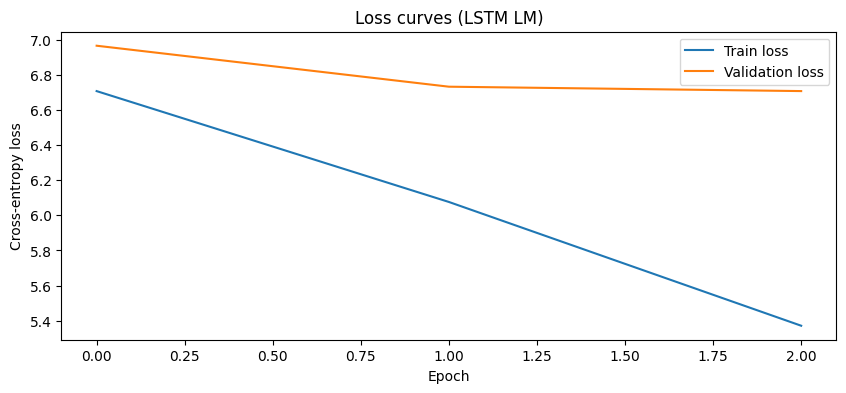

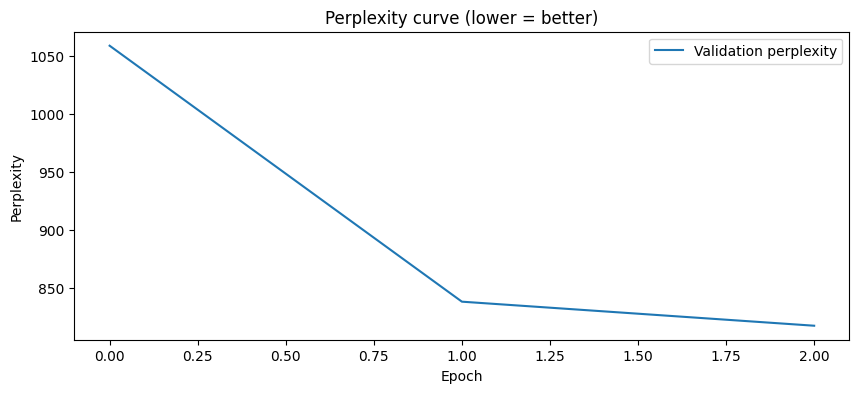

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss curves (LSTM LM)")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["ppl"], label="Validation perplexity")
plt.title("Perplexity curve (lower = better)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()
